## Quantification of MW direction reversal

This code calculates the duration of a complete metachronal wave directional reversal, resulting to a reversal in swimming direction. Detection is using the AFT method, adapted from Marcotti S. et al., Frontiers in Computer Science, 2021 (https://doi.org/10.3389/fcomp.2021.745831)

**Input:**

*file_directory*: Path to folder containing the kymograph to be analyzed.

*file_name*: The name of the pkl with the preprocessed kymograph.

*input_parameters_path* : The path to the file with the input parameters

**Output:**

*parameters.csv*: A csv file with the parameters used in the analysis

*results.csv*: A csv file with the timepoints detected and the reversal duration


In [14]:
import os
import csv
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter       
from skimage.transform import resize

from functions import image_local_order 
### The imported function, image_local_order, (and its helper functions) is copied from:
    # Marcotti S. et al., Frontiers in Computer Science, 2021 (2021), DOI: https://doi.org/10.3389/fcomp.2021.745831, 
    # MIT License (https://github.com/OakesLab/AFT-Alignment_by_Fourier_Transform).
    # Minor modifications were made for the detection of reorientations and breaks in coordiantion
    # in our analysis. 

### Input

In [2]:
### Path to the cell kymograph
file_directory =  "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name      = "corrected_kymograph.pkl"
file_path = file_directory + "\\" + file_name

fps = 1000
pixel_size = 0.46 # μm

### Reading the parameters file
input_parameters_path = file_directory + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

### Optional: Parameters for cropping region of interest
begin = input_parameters["begin"][0]
end = input_parameters["end"][0]
right = input_parameters["right"][0]
left = input_parameters["left"][0]

### Parameters related to AFT and thresholds 
sigma_gaussian = input_parameters["sigma_gaussian"][0]
window_size = input_parameters["window_size"][0]
overlap     = input_parameters["overlap"][0]
threshold_timesteps   = input_parameters["threshold_timesteps"][0]

### For interpolation and clearer visualization
order_interpolation     = input_parameters["order_interpolation"][0]
mode_interpolation   = input_parameters["mode_interpolation"][0]

### Reading the data
c_intensity_original = pd.read_pickle(file_path)

### Creating output path
output_path = file_directory + "output_MW\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [3]:
### Optional: Select ROI for clearer visualization

c_intensity = c_intensity_original.iloc[begin:end, left:right]
c_intensity.columns = range(c_intensity.shape[1])
c_intensity = c_intensity.reset_index(drop=True)
c_intensity.columns.name = 'position along the cilia (\u03BCm)'
c_intensity.index.name = "Time (frames)"

### Pre-processing

Text(0, 0.5, 't (frames)')

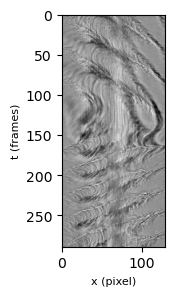

In [4]:
### Plottink the kymograph
fontsize = 8
aspect_ratio = 1 # 200

fig, ax = plt.subplots(figsize=(4,4))
plt.subplots_adjust(left=0.1, bottom=0.3)  # Adjust layout for sliders
im = ax.imshow(c_intensity, aspect = aspect_ratio, cmap="gray", origin = 'lower', extent=[c_intensity.columns[0], c_intensity.columns[-1], c_intensity.index[0], c_intensity.index[-1]])
plt.gca().invert_yaxis()
plt.xlabel('x (pixel)', fontsize = fontsize)
plt.ylabel('t (frames)', fontsize = fontsize)

# c_intensity.to_pickle(output_path + "crop_kymo_start_" + str(begin) + '_end_' + str(end) + '_right_' + str(right) + '_left_' + str(left) +  ".pkl")

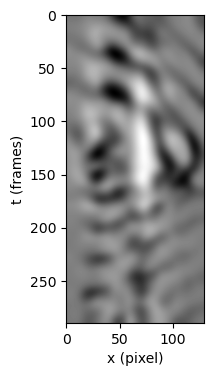

In [5]:
### Smooth blurring to avoid false detection from fine details
aspect_ratio = 1
blurred = gaussian_filter(c_intensity, sigma=sigma_gaussian)
fig, ax = plt.subplots(figsize=(4,4))
plt.imshow(blurred, aspect = aspect_ratio, cmap= "gray")
plt.xlabel('x (pixel)')
plt.ylabel('t (frames)')
np.save(output_path + "blurred.npy", blurred)

### Detection of wave direction with AFT

In [6]:
### Detection of local alignment


rpos, cpos, x, y, u, v, im_theta, im_eccentricity = image_local_order(
    blurred,
    aspect_ratio, 
    window_size, 
    overlap, 
    intensity_thresh=-np.inf,         # Allow all intensity levels
    eccentricity_thresh=0,            # Allow all eccentricities
    save_path = 0,
    plot_overlay=True, 
    plot_angles=True, 
    plot_eccentricity=False,
    save_figures=False
)

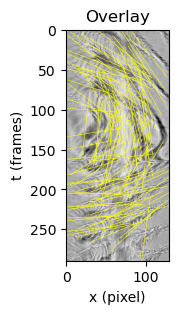

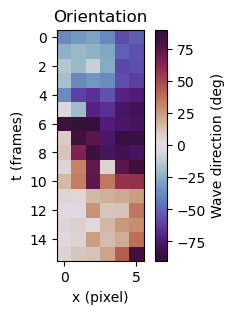

In [7]:
### Visualization of detection
plt.figure(figsize=(3,3))
plt.imshow(c_intensity, cmap='Greys_r', aspect = aspect_ratio)
plt.quiver(x,y,u,v, color='yellow', pivot='mid', scale_units='xy', scale=overlap/2, headaxislength=0, headlength=0, width=0.005)
plt.title('Overlay')
plt.xlabel('x (pixel)')
plt.ylabel('t (frames)')
plt.show()


im_theta_degrees = im_theta * 180 / np.pi
plt.figure(figsize=(3,3))
plt.imshow(im_theta_degrees, vmin=-90, vmax=90, cmap='twilight_shifted', aspect = aspect_ratio) # aspect = 1/2) for viscosity data
cbar = plt.colorbar()
cbar.set_label("Wave direction (deg)")
plt.title('Orientation')
plt.xlabel('x (pixel)')
plt.ylabel('t (frames)')
plt.show()


In [8]:
### Saving the orientation array
np.save(output_path + "orientation.npy", im_theta_degrees)

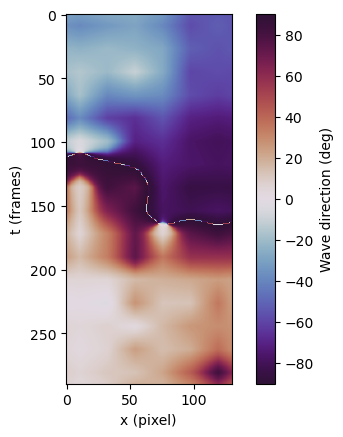

In [9]:
### Interpolation for clearer visualization
theta_deg = im_theta_degrees
theta_rad = np.deg2rad(theta_deg)
x_inter = np.cos(2 * theta_rad)
y_inter = np.sin(2 * theta_rad)

x_up = resize(x_inter, c_intensity.shape, order=order_interpolation, mode=mode_interpolation, anti_aliasing=True)
y_up = resize(y_inter, c_intensity.shape, order=order_interpolation, mode=mode_interpolation, anti_aliasing=True)

theta_up_rad = 0.5 * np.arctan2(y_up, x_up)
im_theta_upsampled = np.rad2deg(theta_up_rad)

plt.imshow(im_theta_upsampled, vmin=-90, vmax=90, cmap='twilight_shifted', alpha=1, aspect=aspect_ratio)
plt.savefig(output_path +"orientation_interpolated.svg", format="svg", transparent=True)
cbar = plt.colorbar()
cbar.set_label("Wave direction (deg)")
plt.xlabel('x (pixel)')
plt.ylabel('t (frames)')
plt.show()

In [10]:
### Saving the interpolated array 
np.save(output_path + "orientation_linear_inerp.npy", im_theta_upsampled)

### Detecting timepoints of interest

Last row where >80% elements >0: 164
First row where >80% elements <0: 113


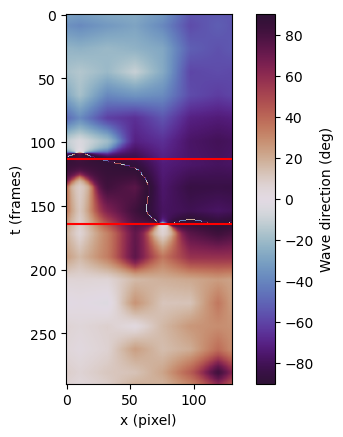

In [11]:
### Computing fraction of elements in positive state per row
frac_pos = np.mean(im_theta_upsampled > 0, axis=1)

# Finding last row that satisfies the condition
rows_pos = np.where(frac_pos > threshold_timesteps)[0]
# detected_start = rows_pos[-1] if len(rows_pos) > 0 else None  
detected_start = rows_pos[0] if len(rows_pos) > 0 else None   ### Alternative to match opposite initial direction

### Computing fraction of elements in negatice state per row
frac_neg = np.mean(im_theta_upsampled < 0, axis=1)

# Finding first row that satisfies the condition
rows_neg = np.where(frac_neg > threshold_timesteps)[0]
# detected_end = rows_neg[0] if len(rows_neg) > 0 else None  
detected_end = rows_neg[-1] if len(rows_neg) > 0 else None   ### Alternative to match opposite initial direction

### Visual evaluation of detection
print("Last row where >80% elements >0:", detected_start)
print("First row where >80% elements <0:", detected_end)

plt.imshow(im_theta_upsampled, vmin=-90, vmax=90, cmap='twilight_shifted', alpha=1, aspect=aspect_ratio)
plt.axhline(detected_start, c="r")
plt.axhline(detected_end, c="r")
cbar = plt.colorbar()
cbar.set_label("Wave direction (deg)")
plt.xlabel('x (pixel)')
plt.ylabel('t (frames)')
plt.show()

delta_t_reversal = np.abs(detected_start-detected_end)/fps

### Saving parameters and results

In [12]:
### Saving parameters
csv_file = output_path + "parameters.csv"

params = {
    "fps": fps,
    "pixel_size": pixel_size,
    "begin": begin,
    "end": end,
    "right": right,
    "left": left,
    "sigma_gaussian": sigma_gaussian,
    "window_size": window_size,
    "overlap": overlap,
    "order_interpolation": order_interpolation,
    "mode_interpolation": mode_interpolation,
    "threshold_timesteps": threshold_timesteps
}

# Write to CSV
with open(csv_file, mode='w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=params.keys())
    writer.writeheader()
    writer.writerow(params)

In [13]:
### Saving results
results_file = output_path + "results.csv"

# Example values (replace with your actual variables)
results = {
    "detected_start (frame)": detected_start,
    "detected_end (frame)": detected_end,
    "delta_t_reversal (sec)": delta_t_reversal
}

with open(results_file, mode='w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=results.keys())
    writer.writeheader()
    writer.writerow(results)